In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('cars_data_post_eda.csv')

In [ ]:
df.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,512000,tata,tiago,3,petrol,20979,manual,fwd,hatchback,5,1199,84.88,5
1,agra,745000,maruti suzuki,baleno,4,petrol,20176,manual,fwd,hatchback,5,1197,81.86,3
2,agra,465000,hyundai,grand i10,3,cng,41448,manual,fwd,hatchback,5,1197,81.86,7
3,agra,546000,maruti suzuki,celerio,3,petrol,8527,manual,fwd,hatchback,5,998,67.04,3
4,agra,428000,hyundai,santro,4,cng,102049,manual,fwd,hatchback,5,1086,68.05,5


In [ ]:
train_df = df[['age', 'odometer', 'engine_cc', 'max_power', 'cylinders', 'fuel', 'transmission', 'type', 'manufacturer', 'price', 'drive', 'seats']]

In [ ]:
train_df.head()

,age,odometer,engine_cc,max_power,cylinders,fuel,transmission,type,manufacturer,price,drive,seats
0,5,20979,1199,84.88,3,petrol,manual,hatchback,tata,512000,fwd,5
1,3,20176,1197,81.86,4,petrol,manual,hatchback,maruti suzuki,745000,fwd,5
2,7,41448,1197,81.86,3,cng,manual,hatchback,hyundai,465000,fwd,5
3,3,8527,998,67.04,3,petrol,manual,hatchback,maruti suzuki,546000,fwd,5
4,5,102049,1086,68.05,4,cng,manual,hatchback,hyundai,428000,fwd,5


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [ ]:
cols_to_ohe = ['fuel' ,'type', 'transmission', 'manufacturer', 'drive']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = ohe.fit_transform(train_df[cols_to_ohe])

In [ ]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols_to_ohe)
)

In [ ]:
train_df = train_df.drop(columns=cols_to_ohe).reset_index(drop=True)
train_df = pd.concat([train_df, encoded_df], axis=1)

<Axes: >

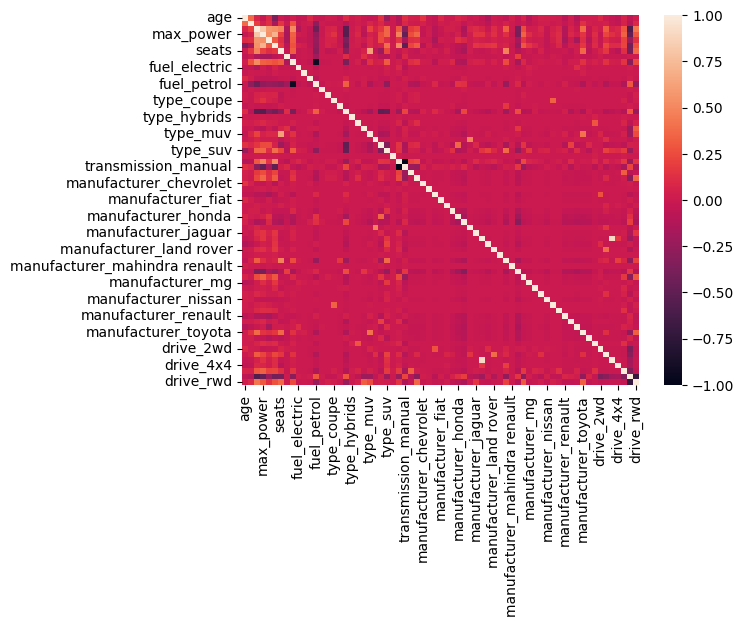

In [ ]:
import seaborn as sns

sns.heatmap(train_df.corr(numeric_only = True))

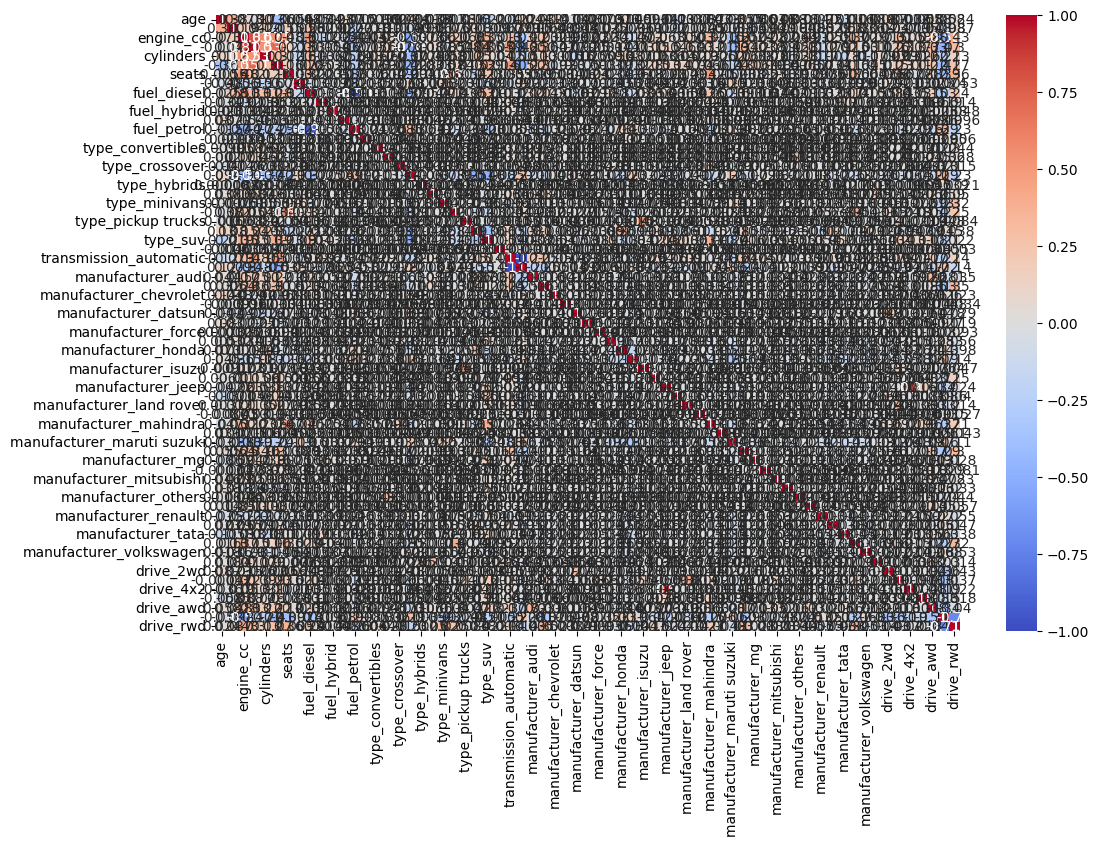

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
X = train_df.drop(columns=['price'])
y = train_df['price']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

,0
max_power,0.604421
age,0.155889
odometer,0.062297
type_suv,0.059002
engine_cc,0.026129
manufacturer_mercedes-benz,0.015631
manufacturer_land rover,0.005718
transmission_automatic,0.005425
transmission_manual,0.005082
seats,0.004501
